# Clustering on Image Dataset

## Objective
Find structure in an unlabelled image dataset using pretrained CNN features, before committing to manual labeling.

**Dataset:** [Dishwasher-Safe or Not](https://www.kaggle.com/datasets/anushreesitaramdas/dishwasher-safe-or-not)
**Blog post:** [Finding Structure in Unstructured Image Dataset](https://medium.com/@anushreedas.2710/finding-structure-in-unstructured-image-dataset-an-initial-analysis-of-unlabelled-data-0cf2f6231735)

## Approach
1. Extract a 4096-dimensional feature vector per image using a pretrained VGG16 model
2. Reduce to 500 dimensions using PCA
3. Cluster with KMeans and explore the resulting groups
4. Use the elbow method to find the optimal number of clusters

## Key Questions
- Do the natural visual clusters align with the manual labels?
- Are any sub-classes visually indistinct from each other?
- Are there noisy or outlier images that should be removed?

## 1. Import Libraries

In [12]:
# Image loading and VGG16 feature extraction
from keras.preprocessing.image import load_img
from keras.applications.vgg16 import VGG16, preprocess_input
from keras.models import Model

# Clustering and dimensionality reduction
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

## 2. Configuration

> **Set `DATA_DIR` and `FEATURES_PKL` to match your local paths before running.**

Features are extracted once and saved to disk as a pickle file. On subsequent runs,
the extraction step is skipped and features are loaded directly from disk.

In [13]:
DATA_DIR = "../data/final_data"
FEATURES_PKL = "../Data/data_features.pkl"
SUPPORTED_EXTENSIONS = ('JPG', 'jpeg', 'png', 'jpg', 'gif', 'webp')

## 3. Load Image Paths

In [14]:
image_paths = []

for root, _, files in os.walk(DATA_DIR):
    for file in files:
        if file.split('.')[-1] in SUPPORTED_EXTENSIONS:
            image_paths.append(os.path.join(root, file))

print(f"Total images found: {len(image_paths)}")
print("Sample paths:")
for p in image_paths[:3]:
    print(" ", p)

Total images found: 1237
Sample paths:
  ../Data/final_data/dishwasher-safe/dinner_knife/Screen Shot 2023-09-22 at 3.46.27 PM.png
  ../Data/final_data/dishwasher-safe/dinner_knife/Screen Shot 2023-09-22 at 3.47.19 PM.png
  ../Data/final_data/dishwasher-safe/dinner_knife/Screen Shot 2023-09-22 at 3.45.26 PM.png


## 4. Feature Extraction with VGG16

We use VGG16 pretrained on ImageNet as a fixed feature extractor. By taking the output
of the second-to-last fully connected layer (`fc2`), we get a 4096-dimensional vector
that captures rich visual semantics for each image — without any task-specific training.

This step is computationally expensive (~1–2 minutes for 1,200 images on CPU).
Features are saved to disk so this only needs to run once.

In [15]:
def build_feature_extractor():
    """Load VGG16 and return a model that outputs fc2 features (4096-d)."""
    base = VGG16()
    return Model(inputs=base.inputs, outputs=base.layers[-2].output)


def extract_features(filepath, model):
    """
    Extract a 4096-dimensional feature vector from a single image.

    Args:
        filepath (str): Path to the image file.
        model: Keras feature extractor model.

    Returns:
        np.ndarray: Feature vector of shape (1, 4096).
    """
    img = load_img(filepath, target_size=(224, 224))
    img = np.array(img).reshape(1, 224, 224, 3)
    img = preprocess_input(img)  # converts RGB→BGR, zero-centers per ImageNet stats
    return model.predict(img, verbose=0)


def extract_and_save_features(image_paths, model, output_path):
    """
    Extract features for all images and save to a pickle file.
    Saves incrementally on error to avoid losing progress.

    Args:
        image_paths (list[str]): Paths to all images.
        model: Keras feature extractor model.
        output_path (str): Destination path for the pickle file.

    Returns:
        dict: Maps filepath → feature vector.
    """
    features_data = {}
    for i, filepath in enumerate(image_paths):
        try:
            features_data[filepath] = extract_features(filepath, model)
            if (i + 1) % 100 == 0:
                print(f"Processed {i + 1}/{len(image_paths)} images")
        except Exception as e:
            print(f"Error on {filepath}: {e}")
            # Save progress so far before continuing
            with open(output_path, 'wb') as f:
                pickle.dump(features_data, f)

    with open(output_path, 'wb') as f:
        pickle.dump(features_data, f)

    print(f"Done. Features saved to {output_path}")
    return features_data

In [16]:
# Load from disk if already extracted; otherwise run extraction
if os.path.exists(FEATURES_PKL):
    print("Loading cached features from disk...")
    with open(FEATURES_PKL, 'rb') as f:
        data = pickle.load(f)
    print(f"Loaded features for {len(data)} images")
else:
    print("Extracting features (this may take a few minutes)...")
    extractor = build_feature_extractor()
    data = extract_and_save_features(image_paths, extractor, FEATURES_PKL)

Extracting features (this may take a few minutes)...
Processed 100/1237 images
Processed 200/1237 images
Processed 300/1237 images
Processed 400/1237 images
Processed 500/1237 images
Processed 600/1237 images
Processed 700/1237 images
Processed 800/1237 images
Processed 900/1237 images
Processed 1000/1237 images
Processed 1100/1237 images
Processed 1200/1237 images
Done. Features saved to ../Data/data_features.pkl


## 5. Dimensionality Reduction with PCA

4096 dimensions is too high for KMeans to work well — the algorithm suffers in
high-dimensional spaces (the "curse of dimensionality"). We reduce to 500 components,
which retains the majority of variance while making clustering tractable.

We print the variance retained so the choice of 500 components is justified, not arbitrary.

In [17]:
def apply_pca(data, n_components=500):
    """
    Reduce VGG16 feature vectors from 4096 to n_components dimensions.

    Args:
        data (dict): Maps filepath → feature vector (shape: (1, 4096)).
        n_components (int): Number of PCA components to retain.

    Returns:
        tuple: (reduced feature matrix, fitted PCA object)
    """
    features = np.array(list(data.values())).reshape(-1, 4096)

    pca = PCA(n_components=n_components, random_state=22)
    pca.fit(features)
    x = pca.transform(features)

    variance_retained = pca.explained_variance_ratio_.sum()
    print(f"Dimensions: {features.shape[1]} → {n_components}")
    print(f"Variance retained: {variance_retained:.2%}")

    return x, pca


X_pca, pca_model = apply_pca(data, n_components=500)

Dimensions: 4096 → 500
Variance retained: 95.64%


## 6. Choosing the Number of Clusters (Elbow Method)

We fit KMeans for a range of k values and plot the sum of squared errors (SSE) for each.
The "elbow" — where adding more clusters stops meaningfully reducing SSE — gives a
reasonable estimate for k.

> **Note:** This cell is slow. Run it once to identify the elbow, then use the result
> to set `K` in Section 7. The range below is intentionally narrow for speed — widen
> it if you need a more precise estimate.

k=10, SSE=3434264.00
k=20, SSE=3059070.00
k=30, SSE=2855636.00
k=40, SSE=2674072.50
k=50, SSE=2544566.25
k=60, SSE=2463633.25
k=70, SSE=2360010.25
k=80, SSE=2275897.25
k=90, SSE=2193463.50
k=100, SSE=2126226.50
k=110, SSE=2076114.75


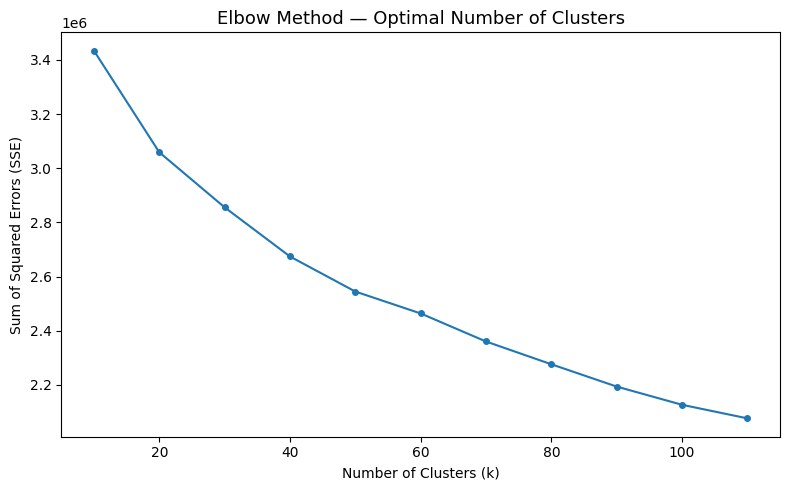

In [18]:
def find_optimal_k(X, k_range):
    """
    Compute SSE for each k in k_range and plot the elbow curve.

    Args:
        X (np.ndarray): Reduced feature matrix.
        k_range (range): Range of k values to evaluate.
    """
    sse = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=22, n_init='auto')
        km.fit(X)
        sse.append(km.inertia_)
        print(f"k={k}, SSE={km.inertia_:.2f}")

    plt.figure(figsize=(8, 5))
    plt.plot(list(k_range), sse, marker='o', markersize=4)
    plt.title('Elbow Method — Optimal Number of Clusters', fontsize=13)
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Sum of Squared Errors (SSE)')
    plt.tight_layout()
    plt.savefig('../images/elbow_curve.png', dpi=150)
    plt.show()


find_optimal_k(X_pca, k_range=range(10, 120, 10))

## 7. Clustering with KMeans

Based on the elbow curve above, the SSE slope flattens around k=60. We use this as our
cluster count — slightly above the 55 manually defined sub-classes, which is a useful
sanity check that the clustering is capturing real visual groupings.

In [19]:
def create_clusters(data, X_pca, k):
    """
    Fit KMeans on PCA-reduced features and group image paths by cluster label.

    Args:
        data (dict): Maps filepath → feature vector.
        X_pca (np.ndarray): PCA-reduced feature matrix.
        k (int): Number of clusters.

    Returns:
        dict: Maps cluster_id (int) → list of image filepaths.
    """
    filenames = np.array(list(data.keys()))

    kmeans = KMeans(n_clusters=k, random_state=22, n_init='auto')
    kmeans.fit(X_pca)

    clusters = {}
    for filepath, label in zip(filenames, kmeans.labels_):
        clusters.setdefault(label, []).append(filepath)

    return clusters


K = 60
clusters = create_clusters(data, X_pca, k=K)
print(f"Created {len(clusters)} clusters")
print(f"Largest cluster: {max(len(v) for v in clusters.values())} images")
print(f"Smallest cluster: {min(len(v) for v in clusters.values())} images")

Created 60 clusters
Largest cluster: 50 images
Smallest cluster: 2 images


## 8. Visualizing Clusters

The visualization below shows up to 30 images per cluster. Look for:
- **Coherent clusters:** all images show the same object type → good
- **Mixed clusters:** images from different sub-classes grouped together → these categories may be visually indistinct
- **Noise clusters:** unusual lighting, cropped objects, cluttered backgrounds → candidates for removal

In [20]:
def view_cluster(cluster_images, cluster_id, max_display=30):
    """
    Display a grid of images from a single cluster.

    Args:
        cluster_images (list[str]): Image filepaths in the cluster.
        cluster_id (int): Cluster identifier (used in the title).
        max_display (int): Maximum number of images to show.
    """
    display_images = cluster_images[:max_display]
    n = len(display_images)
    cols = 10
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(20, 2 * rows))
    fig.suptitle(f"Cluster {cluster_id} — {len(cluster_images)} images", fontsize=12)

    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()
    for i, ax in enumerate(axes):
        if i < n:
            img = np.array(load_img(display_images[i]))
            ax.imshow(img)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# View all clusters — comment this out and use the cell below
# to inspect specific clusters by ID instead
for cluster_id, images in sorted(clusters.items()):
    view_cluster(images, cluster_id)

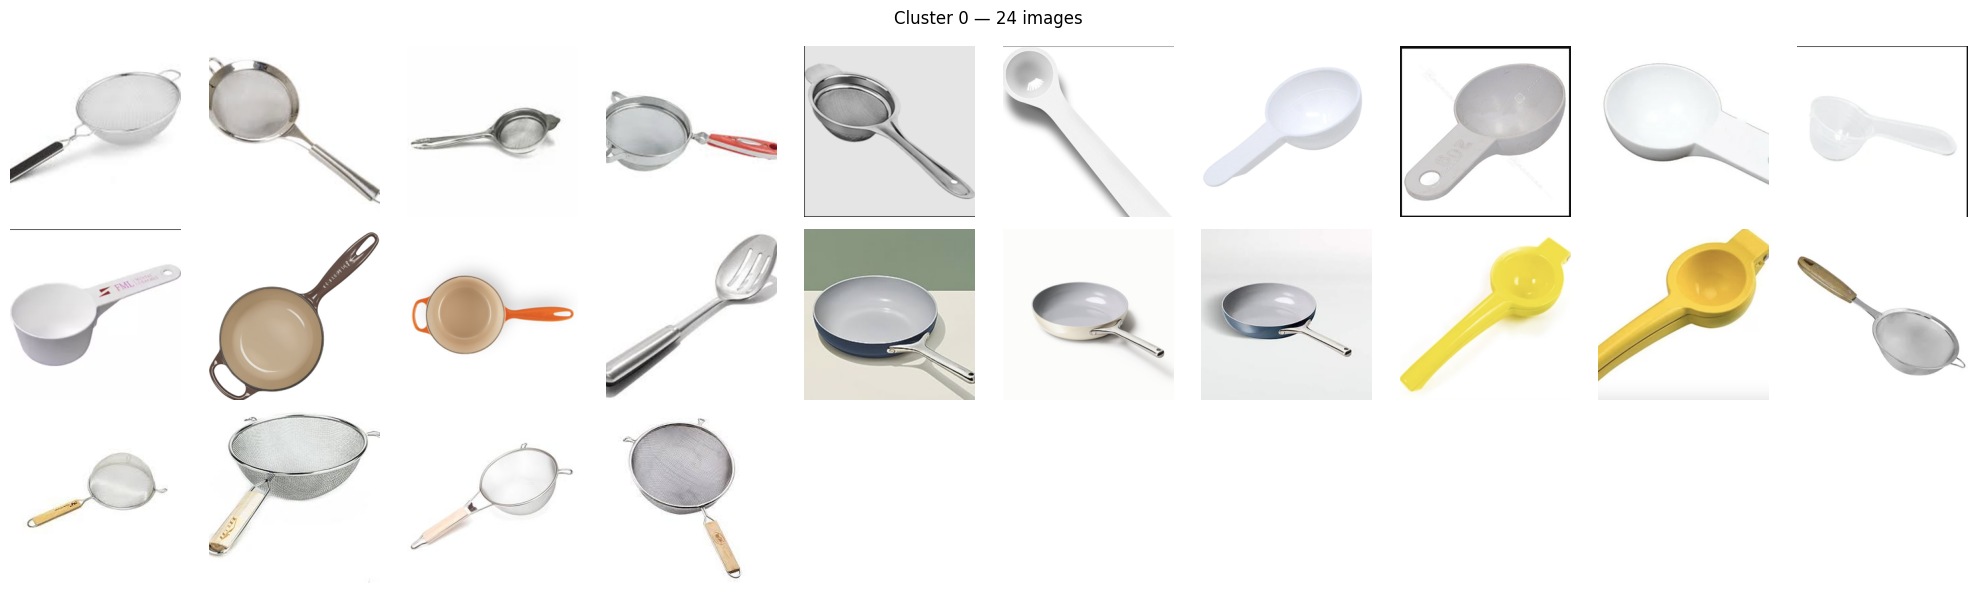

In [22]:
# Inspect a specific cluster by ID
CLUSTER_ID = 0
view_cluster(clusters[CLUSTER_ID], CLUSTER_ID)

## 9. Observations

Reviewing the clusters revealed three things that the folder structure alone couldn't show:

**1. Some manually defined sub-classes are visually indistinct.**
Certain clusters pulled together images from two or three different labeled categories —
for example, measuring cups and pots with long handle frequently appeared in the same cluster.
This suggests the model will likely struggle to separate those categories and that they
may need more distinctive examples.

**2. Cluster sizes are highly uneven.**
A handful of clusters contained 80–100 images while others had fewer than 10. This
confirms that the dataset is imbalanced not just at the label level, but at the visual
feature level too — a subtler problem that label counts alone don't reveal.

**3. Some clusters are clearly noise.**
Images with unusual lighting, extreme crops, or backgrounds that dominated the frame
formed their own small clusters. Identifying these before labeling meant removing
confusing examples rather than training on them.

None of this required a single label. Clustering on raw visual features gave a map
of the dataset before any annotation work, and changed several data collection and
preprocessing decisions made downstream.

**Next step:** The cleaned, labeled dataset was used to train a ResNet-based classifier.

---
**Author:** Anushree Das
**LinkedIn:** [anushree-s-das](https://www.linkedin.com/in/anushree-s-das)
**GitHub:** [anushreedas](https://github.com/anushreedas)
**Blog post:** [Finding Structure in Unstructured Image Dataset](https://medium.com/@anushreedas.2710/finding-structure-in-unstructured-image-dataset-an-initial-analysis-of-unlabelled-data-0cf2f6231735)